# ATP Tennis Match Predictor

Predicting ATP singles match winners with Elo ratings (overall + surface-specific) and XGBoost, trained on [Jeff Sackmann's tennis_atp data](https://github.com/JeffSackmann/tennis_atp) (CC BY-NC-SA 4.0, 1991–present).

Pipeline: **EDA → Elo → leakage-safe features → baselines vs XGBoost → evaluation → on-demand prediction.**

## 1. Load & clean data

In [1]:
import sys; sys.path.append("..")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

from src.data import load_matches, clean_matches
from src.elo import compute_elo, expected_score
from src.features import build_features, add_history_features, FEATURE_COLUMNS

df = clean_matches(load_matches("../data/raw"))
print(df.shape, df["tourney_date"].min().date(), "->", df["tourney_date"].max().date())


(112588, 49) 1990-12-31 -> 2026-05-17


## 2. Exploratory data analysis

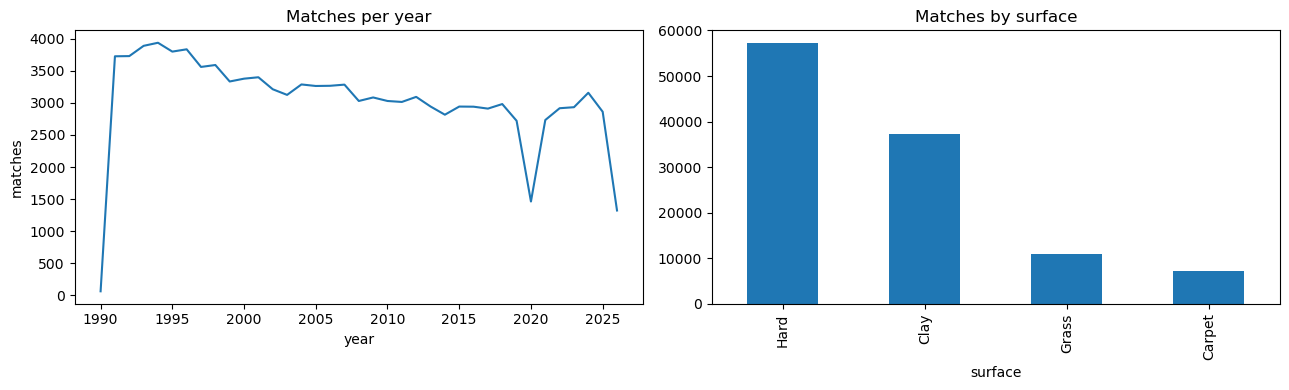

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df.groupby(df["tourney_date"].dt.year).size().plot(ax=ax[0], title="Matches per year")
ax[0].set_xlabel("year"); ax[0].set_ylabel("matches")
df["surface"].value_counts().plot.bar(ax=ax[1], title="Matches by surface")
plt.tight_layout(); plt.show()


## 3. Compute Elo and build leakage-safe features

Elo is computed chronologically; each match records the players' **pre-match** ratings before updating. History features (recent form, head-to-head, rest days) use only prior matches.

In [3]:
df_elo, ratings, surface_ratings = compute_elo(df)
df_hist = add_history_features(df_elo, window=10)
feats = build_features(df_hist, seed=42).dropna(subset=FEATURE_COLUMNS).reset_index(drop=True)
print("feature rows:", len(feats), "| a_won mean:", round(feats["a_won"].mean(), 3))
feats[FEATURE_COLUMNS].describe().T[["mean", "std", "min", "max"]]


feature rows: 105389 | a_won mean: 0.501


,mean,std,min,max
elo_diff,0.373822,203.653982,-956.946167,956.345104
surface_elo_diff,-0.109248,209.707362,-1090.207356,1016.179732
rank_diff,-0.017535,140.229868,-1890.000000,2094.000000
rank_points_diff,3.650305,1925.540535,-16641.000000,16516.000000
age_diff,0.000361,5.219762,-21.500000,25.900000
height_diff,0.010257,9.354073,-176.000000,188.000000
recent_winpct_diff,0.000949,0.240589,-1.000000,1.000000
h2h_diff,-0.005114,1.523896,-23.000000,21.000000
days_since_last_diff,0.094611,114.418057,-4549.000000,4133.000000


## 4. Time-based train/validation/test split

No shuffling — we train on the past and test on the future, mirroring real prediction.

In [4]:
def split_by_year(feats, train_end="2018-12-31", valid_end="2021-12-31"):
    tr = feats[feats["tourney_date"] <= train_end]
    va = feats[(feats["tourney_date"] > train_end) & (feats["tourney_date"] <= valid_end)]
    te = feats[feats["tourney_date"] > valid_end]
    return tr, va, te

train, valid, test = split_by_year(feats)
X_cols = FEATURE_COLUMNS
print("train:", len(train), "valid:", len(valid), "test:", len(test))


train: 85807 valid: 6783 test: 12799


## 5. Baselines

**Baseline 1:** higher-ranked player wins. **Baseline 2:** pure Elo win probability.

In [5]:
rank_pred = (test["rank_diff"] < 0).astype(int)
acc_rank = accuracy_score(test["a_won"], rank_pred)

elo_p = 1 / (1 + 10 ** (-test["elo_diff"].values / 400))
acc_elo = accuracy_score(test["a_won"], (elo_p > 0.5).astype(int))
ll_elo = log_loss(test["a_won"], elo_p)
print(f"Higher-rank accuracy: {acc_rank:.4f}")
print(f"Elo accuracy: {acc_elo:.4f} | log_loss: {ll_elo:.4f}")


Higher-rank accuracy: 0.6392
Elo accuracy: 0.6413 | log_loss: 0.6361


## 6. XGBoost on the full feature set

In [6]:
model = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
)
model.fit(train[X_cols], train["a_won"],
          eval_set=[(valid[X_cols], valid["a_won"])], verbose=False)
xgb_p = model.predict_proba(test[X_cols])[:, 1]
acc_xgb = accuracy_score(test["a_won"], (xgb_p > 0.5).astype(int))
ll_xgb = log_loss(test["a_won"], xgb_p)
print(f"XGBoost accuracy: {acc_xgb:.4f} | log_loss: {ll_xgb:.4f}")


XGBoost accuracy: 0.6533 | log_loss: 0.6160


## 7. Model comparison, calibration, and feature importance

,model,accuracy,log_loss,brier,auc
0,Higher rank,0.6392,NaN,NaN,NaN
1,Elo,0.6413,0.6361,0.2222,0.6995
2,XGBoost,0.6533,0.6160,0.2143,0.7164


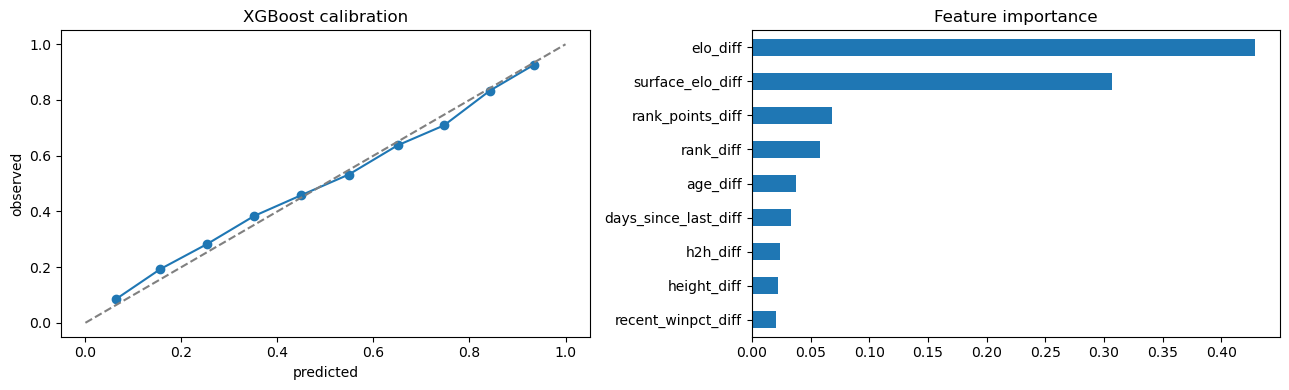

In [7]:
results = pd.DataFrame({
    "model": ["Higher rank", "Elo", "XGBoost"],
    "accuracy": [acc_rank, acc_elo, acc_xgb],
    "log_loss": [np.nan, ll_elo, ll_xgb],
    "brier": [np.nan, brier_score_loss(test["a_won"], elo_p), brier_score_loss(test["a_won"], xgb_p)],
    "auc": [np.nan, roc_auc_score(test["a_won"], elo_p), roc_auc_score(test["a_won"], xgb_p)],
})
display(results.round(4))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
frac, mean = calibration_curve(test["a_won"], xgb_p, n_bins=10)
ax[0].plot(mean, frac, "o-"); ax[0].plot([0, 1], [0, 1], "--", color="gray")
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("observed"); ax[0].set_title("XGBoost calibration")
pd.Series(model.feature_importances_, index=X_cols).sort_values().plot.barh(ax=ax[1], title="Feature importance")
plt.tight_layout(); plt.show()


## 8. Train final model on all data and save artifacts

In [8]:
from src.predict import save_artifacts
final = XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                      subsample=0.9, colsample_bytree=0.9, eval_metric="logloss")
final.fit(feats[X_cols], feats["a_won"])

names = (pd.concat([
    df[["winner_id", "winner_name"]].rename(columns={"winner_id": "id", "winner_name": "name"}),
    df[["loser_id", "loser_name"]].rename(columns={"loser_id": "id", "loser_name": "name"}),
]).drop_duplicates("id").set_index("id")["name"].to_dict())

state = {"ratings": ratings, "surface_ratings": surface_ratings,
         "names": names, "feature_columns": X_cols}
save_artifacts("../models", final, state)
print("saved model + state for", len(names), "players")


saved model + state for 3706 players


## 9. On-demand prediction

Type any two current players and a surface. (History features default to neutral for a hypothetical future match; Elo carries the signal.)

In [9]:
from src.predict import load_artifacts, predict_proba
m, st = load_artifacts("../models")

for a, b, surface in [("Alcaraz", "Sinner", "Clay"),
                      ("Djokovic", "Alcaraz", "Hard"),
                      ("Nadal", "Federer", "Clay")]:
    p = predict_proba(m, st, a, b, surface)
    print(f"{a:>10} vs {b:<10} on {surface:<5}  P({a} wins) = {p:.1%}")


   Alcaraz vs Sinner     on Clay   P(Alcaraz wins) = 93.6%
  Djokovic vs Alcaraz    on Hard   P(Djokovic wins) = 43.0%
     Nadal vs Federer    on Clay   P(Nadal wins) = 52.0%
